## 1. Data Preparation and Exploration

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
# Load Dataset
df = pd.read_csv("/Users/piyush/Downloads/Epileptic_featured _data.csv")

In [3]:
# Inspect: number of samples and features
df.shape

(198, 42)

In [4]:
df

,ID,pow_d,fr_d,cd1_d,cd2_d,cd3_d,cd4_d,cd5_d,cd6_d,pow_t,...,cd6_b,pow_g,fr_g,cd1_g,cd2_g,cd3_g,cd4_g,cd5_g,cd6_g,stat
0,104,0.002738,-5.6583,0.036320,0.085263,0.080991,-0.074508,-0.009881,-0.013535,0.005737,...,-0.12401,0.14298,-3.6805,0.262470,0.61617,0.58529,-0.53844,-0.071407,-0.097813,1
1,116,0.001038,-5.1795,0.084537,0.072065,-0.040925,-0.137560,0.042706,0.062946,0.002779,...,0.41673,0.58351,-3.1111,-0.080878,-1.10330,-1.83840,0.42514,0.496830,0.712690,1
2,117,0.008285,-4.7623,0.031132,0.118660,0.072105,-0.093199,0.042200,-0.021422,0.018769,...,0.85930,0.15079,-2.5285,-1.685500,-1.22000,0.63104,2.56250,-0.426800,-1.241900,1
3,124,0.043148,-4.2379,0.032466,0.196810,0.171380,-0.181750,0.030270,-0.059835,0.082812,...,-1.02680,11.21600,-1.5565,1.613700,4.83660,6.15950,-3.88050,-1.664800,-1.540100,1
4,134,0.057360,-3.8907,0.112120,0.214150,0.065827,-0.291960,0.120500,-0.002113,0.093434,...,-5.06020,7.04690,-1.5676,4.731700,-1.21520,-9.56020,-5.08090,3.472300,6.459600,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,953,3081.800000,1.6067,145.080000,195.280000,-58.626000,-38.425000,-198.380000,-79.629000,698.170000,...,-84.21800,4031.90000,1.8174,-155.130000,-42.31700,115.49000,80.51500,-261.440000,54.857000,2
194,963,3133.200000,1.5565,124.050000,192.080000,-44.501000,-7.592500,-187.010000,-69.065000,549.670000,...,79.42900,86.42700,1.6971,-89.372000,17.52500,-24.92400,55.28900,-508.360000,154.750000,2
195,973,3079.700000,1.5147,99.366000,186.840000,-30.289000,23.385000,-171.440000,-56.570000,373.610000,...,176.22000,3300.50000,1.6213,149.530000,-2.06320,-160.97000,-195.04000,491.100000,-51.282000,2
196,983,2927.700000,1.4758,71.948000,179.820000,-16.396000,53.675000,-152.270000,-42.541000,224.250000,...,82.01200,38.80700,1.6906,-38.799000,61.92900,225.62000,46.63900,277.760000,-91.639000,2


In [5]:
df.columns

Index(['ID', 'pow_d', 'fr_d', 'cd1_d', 'cd2_d', 'cd3_d', 'cd4_d', 'cd5_d',
       'cd6_d', 'pow_t', 'fr_t', 'cd1_t', 'cd2_t', 'cd3_t', 'cd4_t', 'cd5_t',
       'cd6_t', 'pow_a', 'fr_a', 'cd1_a', 'cd2_a', 'cd3_a', 'cd4_a', 'cd5_a',
       'cd6_a', 'pow_b', 'fr_b', 'cd1_b', 'cd2_b', 'cd3_b', 'cd4_b', 'cd5_b',
       'cd6_b', 'pow_g', 'fr_g', 'cd1_g', 'cd2_g', 'cd3_g', 'cd4_g', 'cd5_g',
       'cd6_g', 'stat'],
      dtype='str')

In [6]:
df.isna().sum()

ID       0
pow_d    0
fr_d     0
cd1_d    0
cd2_d    0
cd3_d    0
cd4_d    0
cd5_d    0
cd6_d    0
pow_t    0
fr_t     0
cd1_t    0
cd2_t    0
cd3_t    0
cd4_t    0
cd5_t    0
cd6_t    0
pow_a    0
fr_a     0
cd1_a    0
cd2_a    0
cd3_a    0
cd4_a    0
cd5_a    0
cd6_a    0
pow_b    0
fr_b     0
cd1_b    0
cd2_b    0
cd3_b    0
cd4_b    0
cd5_b    0
cd6_b    0
pow_g    0
fr_g     0
cd1_g    0
cd2_g    0
cd3_g    0
cd4_g    0
cd5_g    0
cd6_g    0
stat     0
dtype: int64

In [7]:
# Initial Data Check
print(df.info())
print(df['stat'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 42 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      198 non-null    int64  
 1   pow_d   198 non-null    float64
 2   fr_d    198 non-null    float64
 3   cd1_d   198 non-null    float64
 4   cd2_d   198 non-null    float64
 5   cd3_d   198 non-null    float64
 6   cd4_d   198 non-null    float64
 7   cd5_d   198 non-null    float64
 8   cd6_d   198 non-null    float64
 9   pow_t   198 non-null    float64
 10  fr_t    198 non-null    float64
 11  cd1_t   198 non-null    float64
 12  cd2_t   198 non-null    float64
 13  cd3_t   198 non-null    float64
 14  cd4_t   198 non-null    float64
 15  cd5_t   198 non-null    float64
 16  cd6_t   198 non-null    float64
 17  pow_a   198 non-null    float64
 18  fr_a    198 non-null    float64
 19  cd1_a   198 non-null    float64
 20  cd2_a   198 non-null    float64
 21  cd3_a   198 non-null    float64
 22  cd4_a   198 n

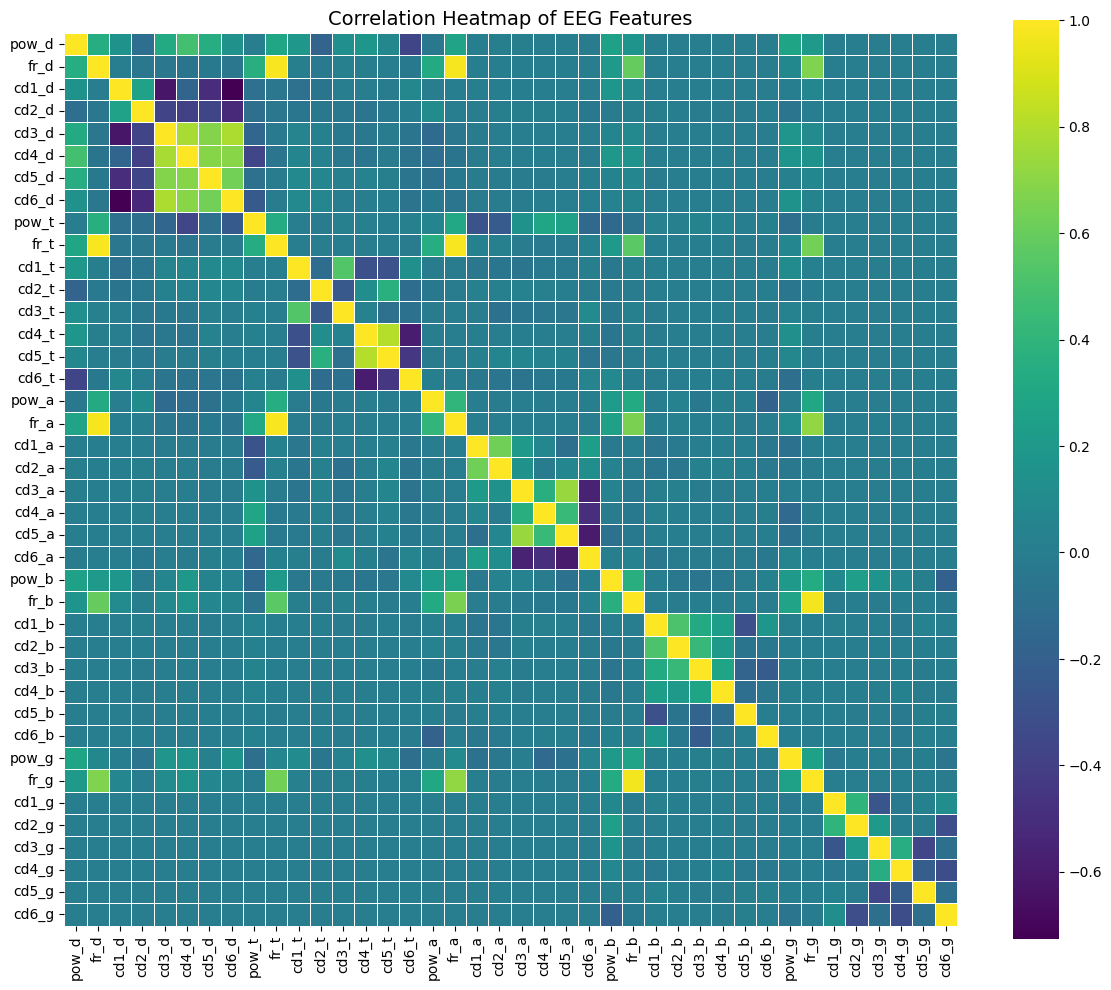

In [8]:
# Correlation Matrix for Feature Analysis 
cols_to_drop = [col for col in ['ID', 'stat'] if col in df.columns]
corr_matrix = df.drop(columns=cols_to_drop).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of EEG Features', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


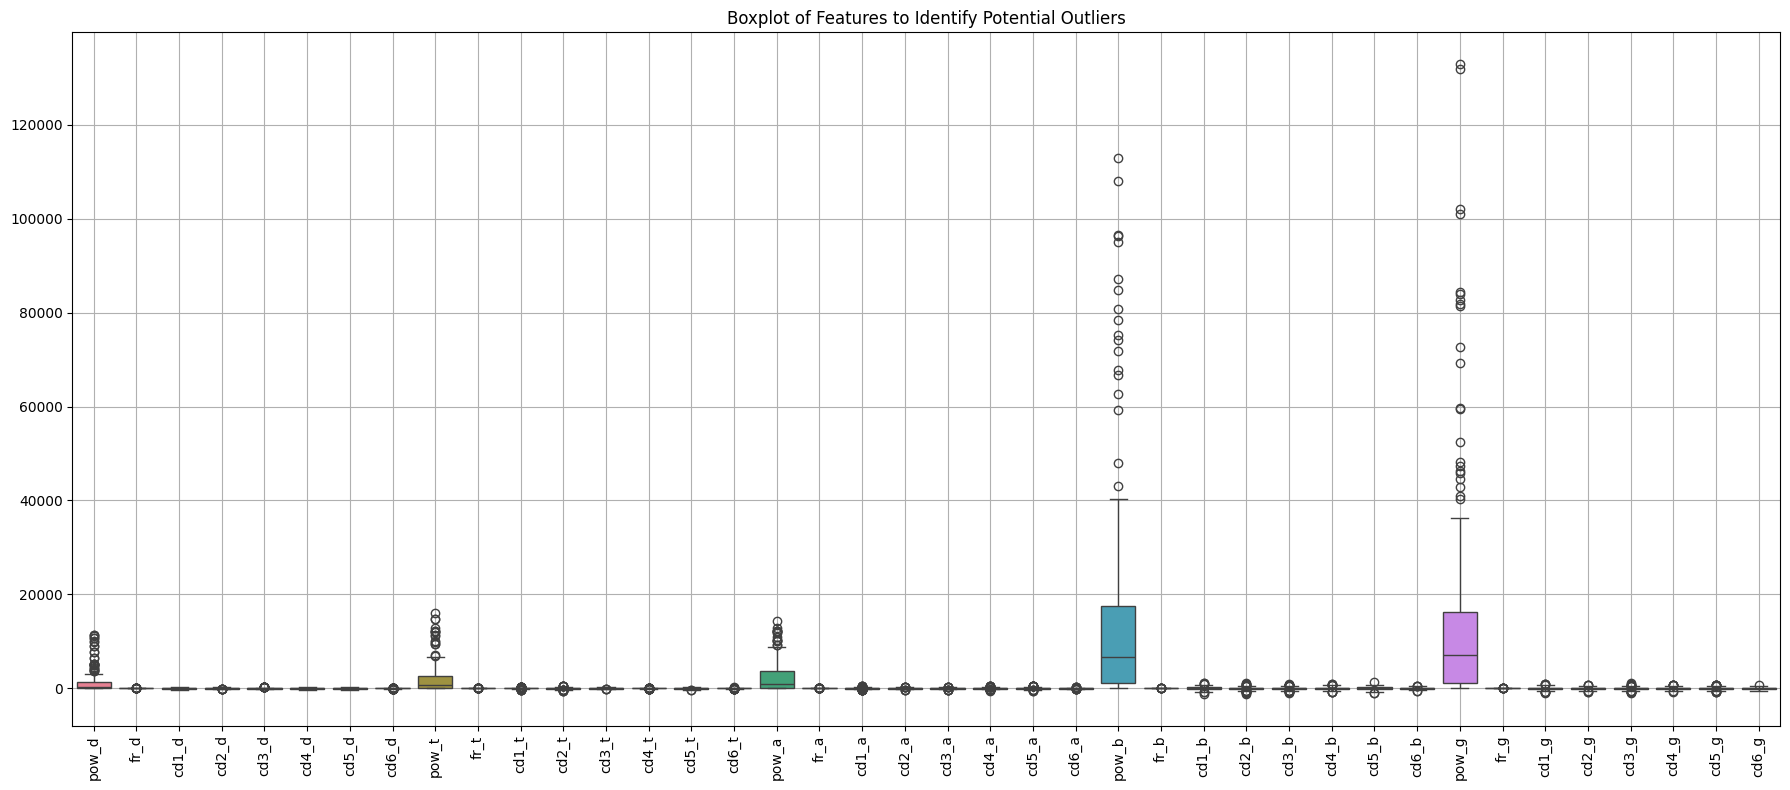

In [9]:
# boxplot for outlier visualization
X = df.drop(columns=['ID', 'stat'])  # EEG feature columns only
y = df['stat'].map({1: 1, 2: 0})     # Binary target mapping

plt.figure(figsize=(18, 8))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title('Boxplot of Features to Identify Potential Outliers')
plt.grid(True)
plt.tight_layout()
plt.show()


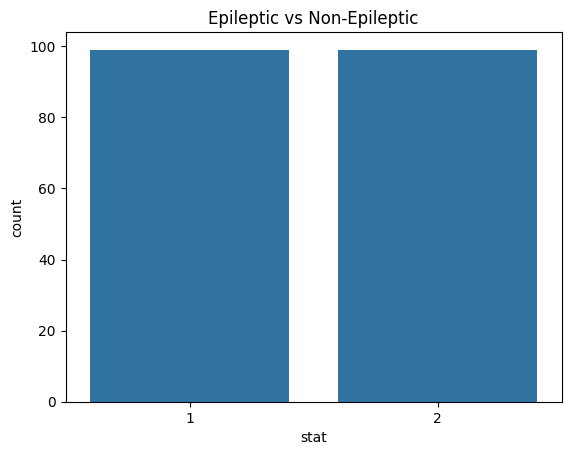

In [10]:
# Visualize Class Balance
sns.countplot(x='stat', data=df)
plt.title('Epileptic vs Non-Epileptic')
plt.show()

## 2. Preprocessing and Feature Scaling

In [11]:
# Preprocess Dataset
df = df.drop('ID', axis=1)
df['stat'] = df['stat'].map({1: 1, 2: 0})
X = df.drop('stat', axis=1)
y = df['stat']

In [12]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Model Selection and Evaluation

Calculating accuracies...
LR: 0.9847 (0.0233)
LDA: 0.9850 (0.0320)
KNN: 0.9650 (0.0391)
DT: 0.9847 (0.0233)
GNB: 0.9545 (0.0270)
SVM: 0.8637 (0.0981)
RF: 1.0000 (0.0000)
BG: 0.9897 (0.0205)
ET: 0.9950 (0.0150)
SGDC: 0.9795 (0.0252)


/var/folders/v0/n6zmy3g14b7fgz793jpxx7g40000gn/T/ipykernel_47801/1539863970.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Accuracy', data=results_long, palette='Set3')


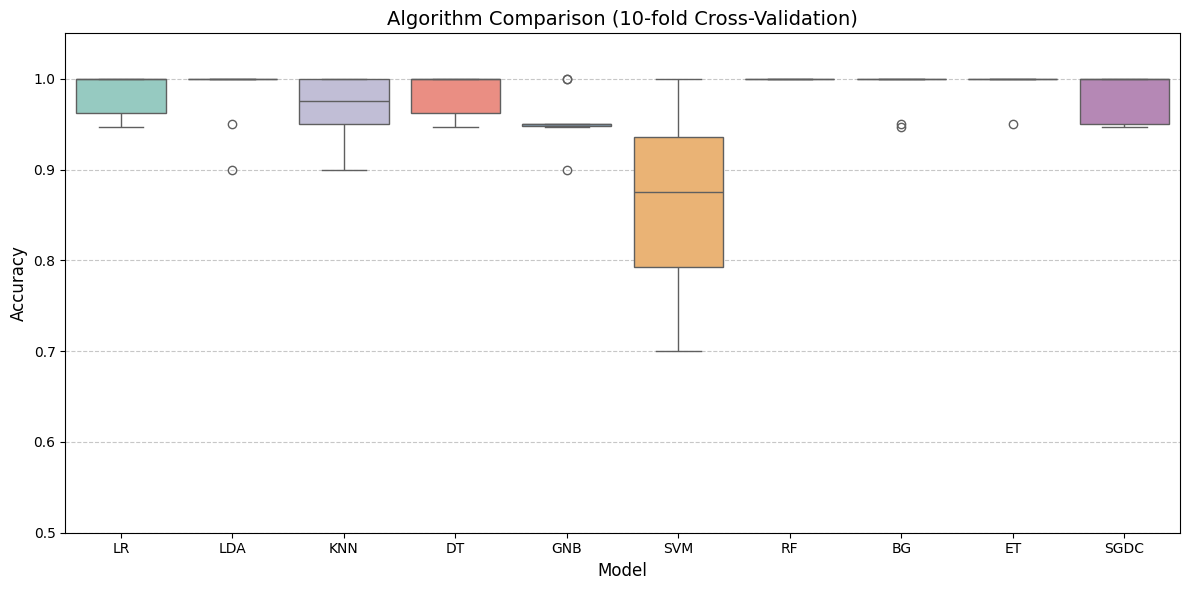

In [13]:
# Model Selection - Evaluation 

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Scale features
X_scaled = StandardScaler().fit_transform(X)

# Prepare models
models = [
    ('LR', LogisticRegression()),
    ('LDA', LinearDiscriminantAnalysis()),
    ('KNN', KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier()),
    ('GNB', GaussianNB()),
    ('SVM', SVC(kernel='poly')),
    ('RF', RandomForestClassifier()),
    ('BG', BaggingClassifier()),
    ('ET', ExtraTreesClassifier()),
    ('SGDC', SGDClassifier())
]

# Evaluate each model
results = []
names = []
print('Calculating accuracies...')
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)
    cv_results = model_selection.cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

# Convert results for seaborn
results_df = pd.DataFrame({name: result for name, result in zip(names, results)})
results_long = results_df.melt(var_name='Model', value_name='Accuracy')

# Create colorful boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Model', y='Accuracy', data=results_long, palette='Set3')
plt.title('Algorithm Comparison (10-fold Cross-Validation)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

In [15]:
# confirm splitting
print(X.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(198, 40) (138, 40) (60, 40) (138,) (60,)


## 4. Model Training

In [16]:
# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
# Train Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
# Train Linear Discriminant Analysis (LDA)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


## 5. Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Logistic Regression Evaluation
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm_lr.ravel()

# Calculate Specificity
specificity_lr = tn / (tn + fp)

# Print all metrics
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_lr):.4f}")
print(f"Specificity: {specificity_lr:.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


Logistic Regression Performance:
Accuracy: 0.9833
Precision: 1.0000
Recall (Sensitivity): 0.9667
Specificity: 1.0000
F1-Score: 0.9831
AUC: 1.0000


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Random Forest Evaluation (Full Features)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm_rf.ravel()

# Calculate Specificity
specificity_rf = tn / (tn + fp)

# Print all metrics
print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_rf):.4f}")
print(f"Specificity: {specificity_rf:.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


Random Forest Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall (Sensitivity): 1.0000
Specificity: 1.0000
F1-Score: 1.0000
AUC: 1.0000


In [21]:
# LDA Evaluation
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:, 1]
cm_lda = confusion_matrix(y_test, y_pred_lda)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm_lda.ravel()

# Calculate Specificity
specificity_lda = tn / (tn + fp)

# Print all metrics
print("LDA Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lda):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_lda):.4f}")
print(f"Specificity: {specificity_lda:.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lda):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_lda):.4f}")


LDA Performance:
Accuracy: 0.9667
Precision: 1.0000
Recall (Sensitivity): 0.9333
Specificity: 1.0000
F1-Score: 0.9655
AUC: 1.0000


## 6. Cross-Validation and Hyperparameter Tuning

In [22]:
# Cross-Validation - Random Forest
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print('Cross-Validation AUC scores:', cv_scores)
print('Mean CV AUC:', np.mean(cv_scores))

Cross-Validation AUC scores: [1. 1. 1. 1. 1.]
Mean CV AUC: 1.0


In [23]:
# Hyperparameter Tuning – Random Forest (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
print("Best parameters:", grid.best_params_)
print("Best cross-validated AUC:", grid.best_score_)


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validated AUC: 1.0


## 7. Full Feature Importance Analysis

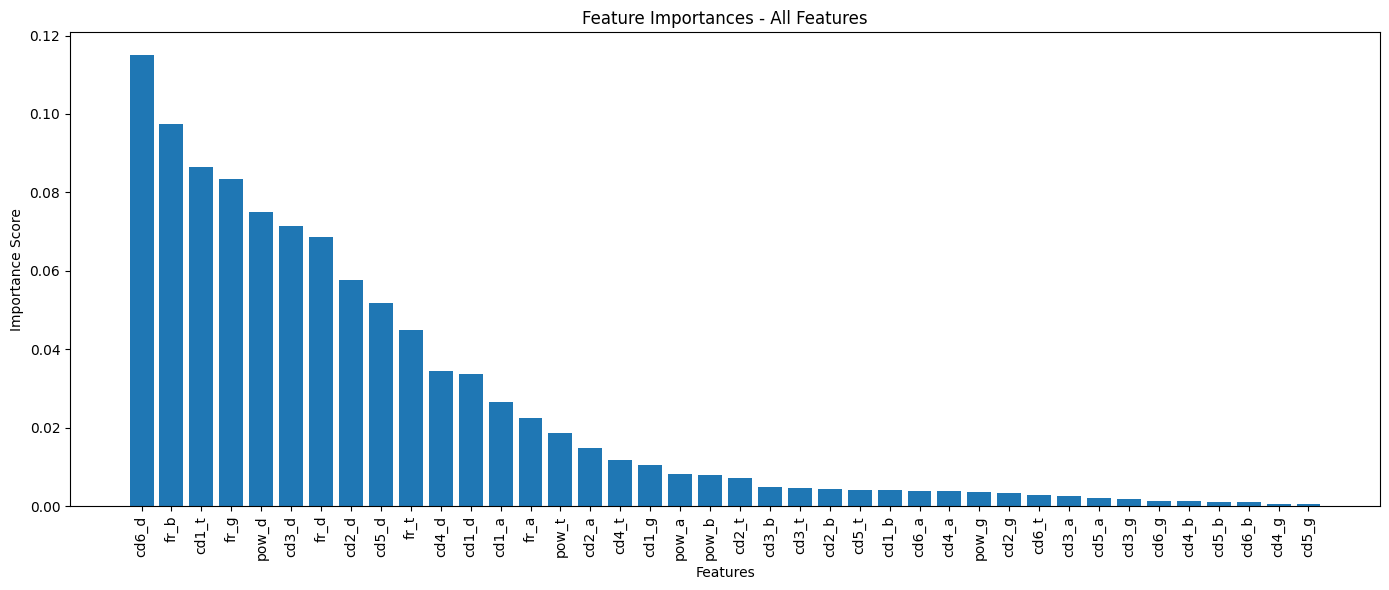

In [24]:
# Full Feature Importance Before Selection
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(14, 6))
plt.title("Feature Importances - All Features")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


## 8. Feature Selection with SelectKBest

In [25]:
# 10 Feature Selection
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support(indices=True)]
print("Top 10 Features:", list(selected_features))

Top 10 Features: ['pow_d', 'fr_d', 'cd2_d', 'cd3_d', 'cd5_d', 'pow_t', 'fr_t', 'pow_a', 'fr_a', 'fr_b']


/var/folders/v0/n6zmy3g14b7fgz793jpxx7g40000gn/T/ipykernel_47801/4258670698.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features, y=top_importances, palette='viridis')


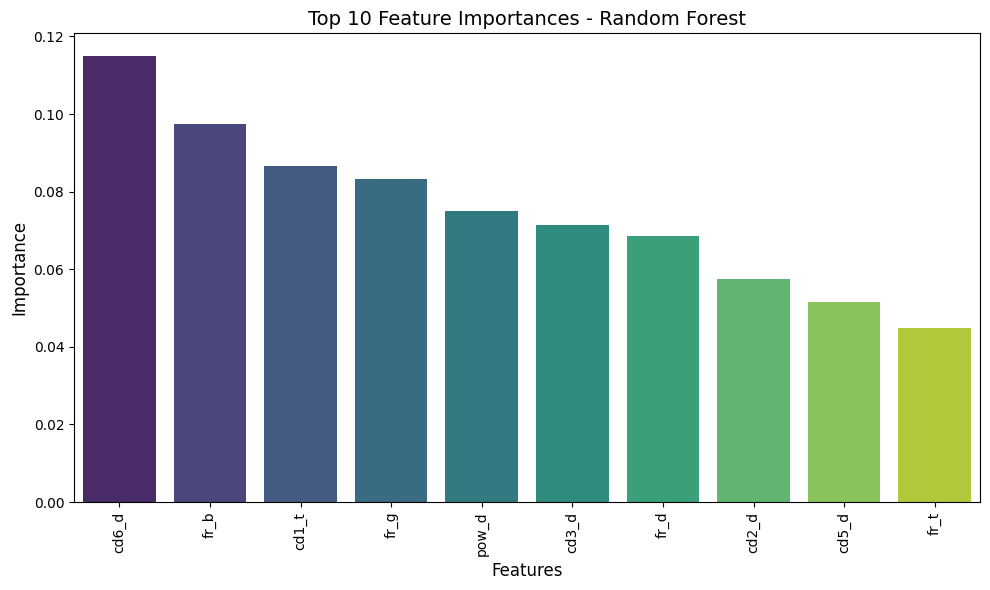

In [26]:
# Feature Importance - Random Forest 

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = [X.columns[i] for i in indices[:10]]
top_importances = importances[indices[:10]]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features, y=top_importances, palette='viridis')

plt.title("Top 10 Feature Importances - Random Forest", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 9. Retraining Random Forest on Selected Features

In [27]:
# Retrain RF on Selected Features
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.3, stratify=y, random_state=42)
rf_sel = RandomForestClassifier()
rf_sel.fit(X_train_sel, y_train_sel)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Evaluate Feature-Selected Random Forest Model
y_pred_sel = rf_sel.predict(X_test_sel)
y_prob_sel = rf_sel.predict_proba(X_test_sel)[:, 1]
cm_sel = confusion_matrix(y_test_sel, y_pred_sel)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm_sel.ravel()

# Calculate Specificity
specificity_sel = tn / (tn + fp)

# Print all metrics
print("Feature-Selected Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test_sel, y_pred_sel):.4f}")
print(f"Precision: {precision_score(y_test_sel, y_pred_sel):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test_sel, y_pred_sel):.4f}")
print(f"Specificity: {specificity_sel:.4f}")
print(f"F1-Score: {f1_score(y_test_sel, y_pred_sel):.4f}")
print(f"AUC: {roc_auc_score(y_test_sel, y_prob_sel):.4f}")


Feature-Selected Random Forest Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall (Sensitivity): 1.0000
Specificity: 1.0000
F1-Score: 1.0000
AUC: 1.0000


## 10. Minimal Feature Set Evaluation

In [29]:
# Minimal Feature Set Evaluation (yeilding AUC > 0.8)
from sklearn.metrics import roc_auc_score, accuracy_score

results = []
for k in [2, 3, 5, 7, 10]:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train_k, y_train)
    y_prob = rf_model.predict_proba(X_test_k)[:, 1]
    y_pred = rf_model.predict(X_test_k)

    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)

    results.append({"Top k Features": k, "AUC": auc, "Accuracy": acc})

df_k_results = pd.DataFrame(results)
df_k_results


,Top k Features,AUC,Accuracy
0,2,0.965000,0.866667
1,3,0.932778,0.866667
2,5,0.982222,0.950000
3,7,1.000000,1.000000
4,10,1.000000,1.000000


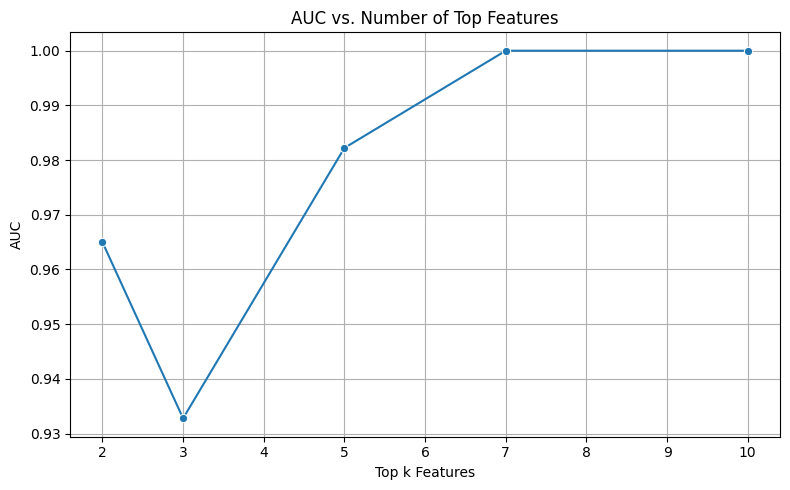

In [30]:

plt.figure(figsize=(8, 5))
sns.lineplot(x='Top k Features', y='AUC', data=df_k_results, marker='o')
plt.title("AUC vs. Number of Top Features")
plt.grid(True)
plt.tight_layout()
plt.show()


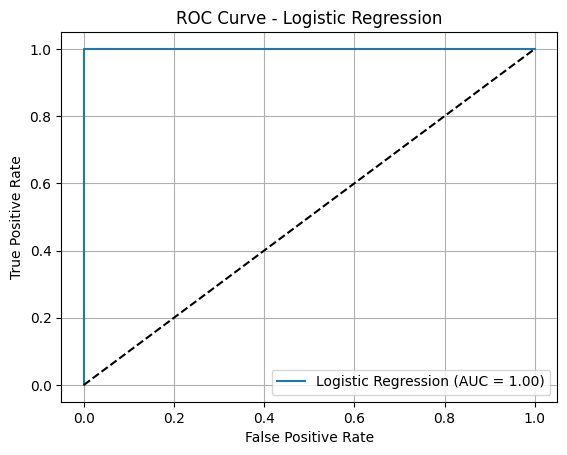

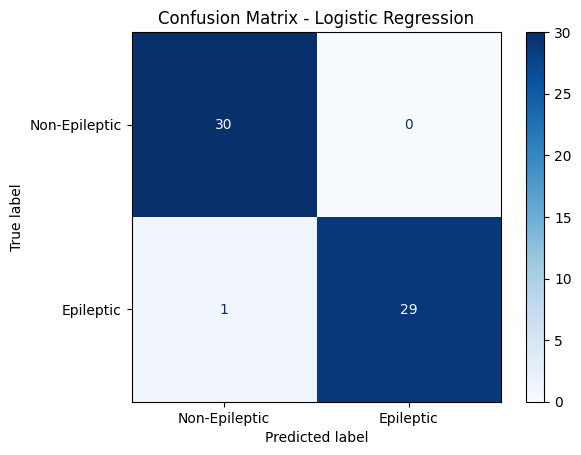

In [31]:
# ROC and Confusion Matrix for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.figure()
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %0.2f)' % roc_auc_score(y_test, y_prob_lr))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Non-Epileptic', 'Epileptic']).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.grid(False)
plt.show()

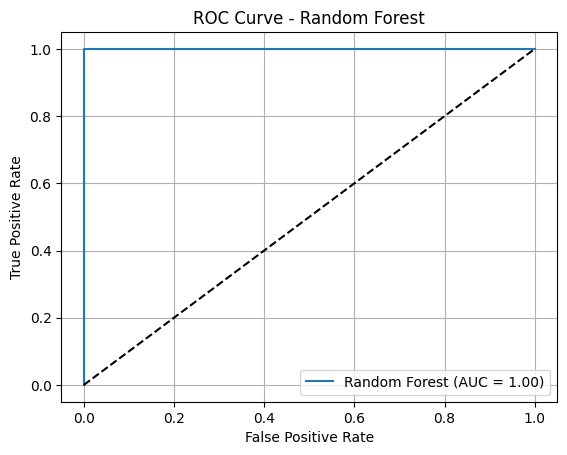

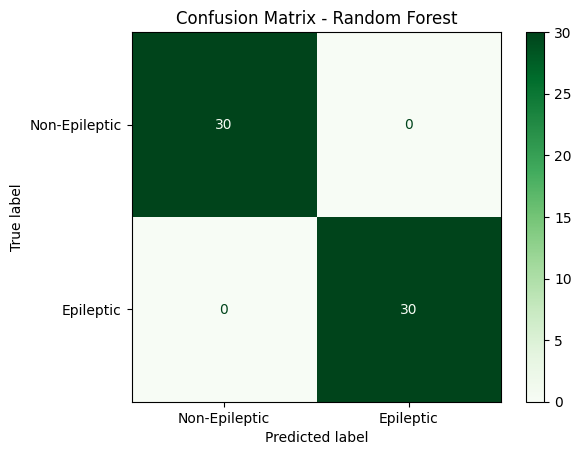

In [32]:
# ROC and Confusion Matrix for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % roc_auc_score(y_test, y_prob_rf))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid()
plt.show()
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Non-Epileptic', 'Epileptic']).plot(cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.grid(False)
plt.show()

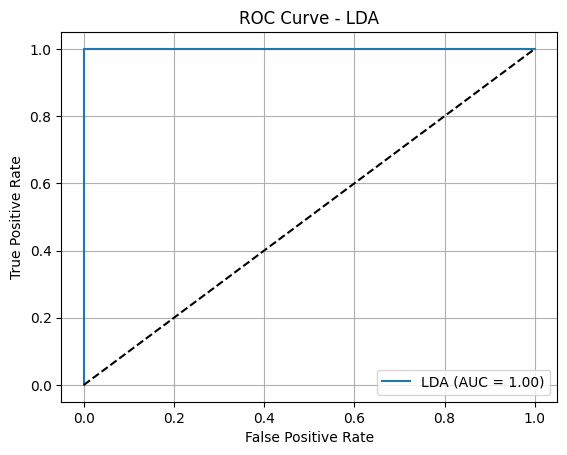

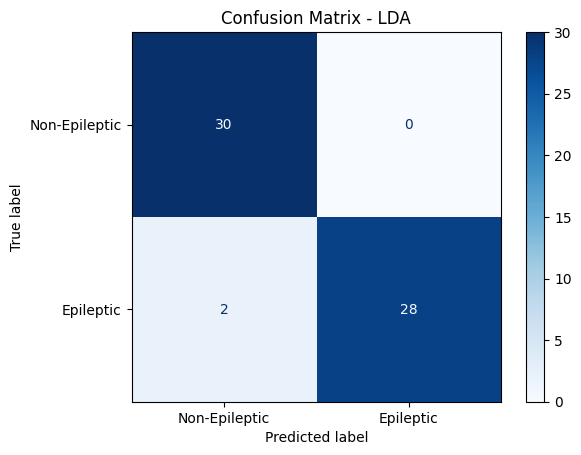

In [33]:
# ROC and Confusion Matrix for LDA
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda)
plt.figure()
plt.plot(fpr_lda, tpr_lda, label='LDA (AUC = %0.2f)' % roc_auc_score(y_test, y_prob_lda))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LDA')
plt.legend()
plt.grid()
plt.show()

cm_lda = confusion_matrix(y_test, y_pred_lda)
ConfusionMatrixDisplay(cm_lda, display_labels=['Non-Epileptic', 'Epileptic']).plot(cmap='Blues')
plt.title('Confusion Matrix - LDA')
plt.grid(False)
plt.show()


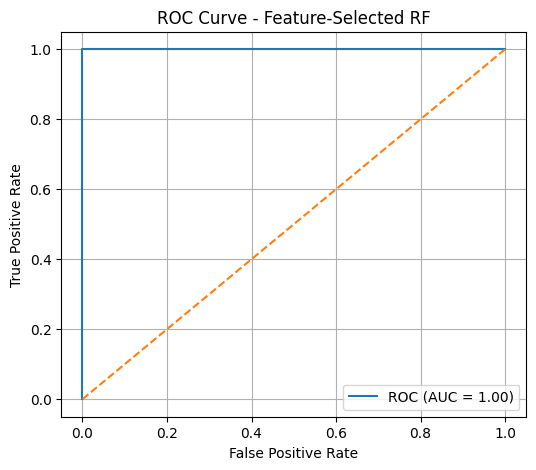

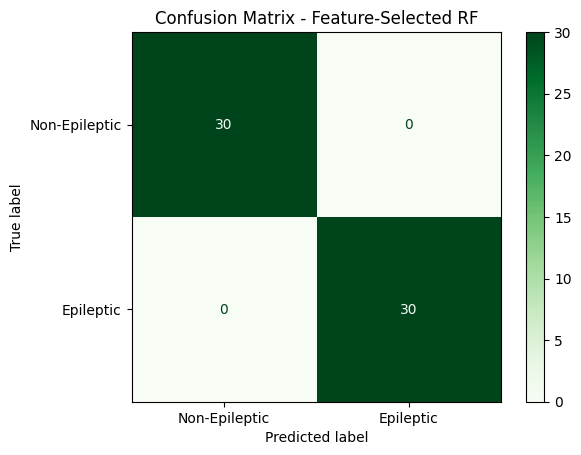

In [34]:
# ROC + Confusion Matrix - Feature-Selected RF
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

fpr_sel, tpr_sel, _ = roc_curve(y_test_sel, y_prob_sel)
roc_auc_sel = auc(fpr_sel, tpr_sel)

plt.figure(figsize=(6, 5))
plt.plot(fpr_sel, tpr_sel, label=f'ROC (AUC = {roc_auc_sel:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Feature-Selected RF')
plt.legend(loc='lower right')
plt.grid()
plt.show()

cm_sel = confusion_matrix(y_test_sel, y_pred_sel)
ConfusionMatrixDisplay(confusion_matrix=cm_sel, display_labels=['Non-Epileptic', 'Epileptic']).plot(cmap='Greens')
plt.title('Confusion Matrix - Feature-Selected RF')
plt.grid(False)
plt.show()


Summary of Key Findings:

Three models were trained: Logistic Regression, Random Forest, and Linear Discriminant Analysis (LDA).

Random Forest achieved the highest overall performance, with an AUC of 1.00 and perfect classification on the test set.

Logistic Regression and LDA also performed strongly, achieving AUC values between 0.98 and 1.00, albeit with slightly lower recall or precision.

Feature selection using SelectKBest allowed the Random Forest model to retain near-perfect classification performance using only the top 10 most informative features.

Findings were validated through 10-fold cross-validation, ROC curve analysis, and confusion matrix evaluation.

The results suggest that machine learning techniques can reliably detect epileptic patterns in EEG-derived features, with Random Forest offering the best trade-off between accuracy, robustness, and interpretability.

